In [91]:
import cv2 as cv
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import joblib

In [92]:
cwd = Path.cwd()

# Prefer local notebook directory if the notebook is already running from misc/prepWork/dev_pictures.
# Otherwise resolve from the repository root.
candidate_paths = [
    cwd / "obj",
    cwd / "misc" / "prepWork" / "dev_pictures" / "obj",
    cwd / "dev_pictures" / "obj",
]

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError(
        f"DATA_PATH not found. Checked: {candidate_paths} (cwd={cwd})"
    )

print("Using DATA_PATH:", DATA_PATH)

Using DATA_PATH: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_pictures/obj


In [93]:
def rotate_image(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)

    M = cv.getRotationMatrix2D(center, angle, 1.0)

    return cv.warpAffine(
        img,
        M,
        (w, h),
        flags=cv.INTER_LINEAR,
        borderValue=(255, 255, 255)
    )


def mirror_image(img):
    return cv.flip(img, 1)

In [94]:
def extract_main_contour(img):

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    blur = cv.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv.threshold(
        blur,
        0,
        255,
        cv.THRESH_BINARY_INV + cv.THRESH_OTSU
    )

    contours, _ = cv.findContours(
        thresh,
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    return max(contours, key=cv.contourArea)

In [95]:
def extract_features(cnt):

    features = {}

    area = cv.contourArea(cnt)
    perimeter = cv.arcLength(cnt, True)

    if area == 0 or perimeter == 0:
        return None

    features["area"] = area
    features["perimeter"] = perimeter

    # Shape approx
    epsilon = 0.04 * perimeter
    approx = cv.approxPolyDP(cnt, epsilon, True)
    features["corners"] = len(approx)

    # Bounding box
    x, y, w, h = cv.boundingRect(cnt)

    features["aspect_ratio"] = w / h
    features["bbox_w"] = w
    features["bbox_h"] = h

    # Circularity
    features["circularity"] = (4 * np.pi * area) / (perimeter ** 2)

    # Solidity
    hull = cv.convexHull(cnt)
    hull_area = cv.contourArea(hull)

    features["solidity"] = area / hull_area if hull_area > 0 else 0

    # Hu Moments
    hu = cv.HuMoments(cv.moments(cnt)).flatten()

    for i in range(7):
        features[f"hu_{i}"] = hu[i]

    return features

In [96]:
angles = [0, 55, 110, 165, 220, 275, 330]

rows = []

In [97]:
for class_dir in DATA_PATH.iterdir():

    if not class_dir.is_dir():
        continue

    label = class_dir.name
    print("Processing:", label)

    for img_path in class_dir.glob("*.png"):

        img = cv.imread(str(img_path))

        if img is None:
            continue

        # Original + augmented versions
        variants = []

        # Rotations
        for angle in angles:
            variants.append(rotate_image(img, angle))

        # Mirror + rotations
        mirrored = mirror_image(img)

        for angle in angles:
            variants.append(rotate_image(mirrored, angle))

        # Feature extraction
        for v in variants:

            cnt = extract_main_contour(v)

            if cnt is None:
                continue

            feat = extract_features(cnt)

            if feat is None:
                continue

            feat["label"] = label

            rows.append(feat)

Processing: unicorn
Processing: cat
Processing: rejected


In [98]:
df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)

df.to_csv("features_dataset.csv", index=False)

df.head()

Dataset shape: (4592, 16)


,area,perimeter,corners,aspect_ratio,bbox_w,bbox_h,circularity,solidity,hu_0,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,label
0,804059.5,9181.711007,4,1.777778,1280,720,0.119854,0.874357,0.205827,0.013216,0.000090,0.000026,1.185025e-09,2.935200e-06,-3.122880e-10,unicorn
1,535486.0,5524.323586,6,1.637500,1179,720,0.220496,0.896989,0.187754,0.006886,0.000060,0.000002,1.359588e-11,1.432161e-07,-2.062600e-11,unicorn
2,512039.0,4435.835902,5,1.373611,989,720,0.327011,0.941466,0.179095,0.004440,0.000088,0.000007,1.702147e-10,3.176996e-07,-3.553745e-11,unicorn
3,755577.5,6163.843041,4,1.777778,1280,720,0.249911,0.936869,0.204574,0.014521,0.000025,0.000007,8.696248e-11,7.834278e-07,-3.722693e-11,unicorn
4,598265.5,6762.461046,4,1.777778,1280,720,0.164397,0.870521,0.207382,0.015163,0.000104,0.000057,4.227432e-09,6.978031e-06,-1.090062e-09,unicorn


Feature dataframe shape: (4592, 16)
Label distribution:
label
unicorn     1582
cat         1554
rejected    1456
Name: count, dtype: int64
Summary statistics:


,area,perimeter,corners,aspect_ratio,bbox_w,bbox_h,circularity,solidity,hu_0,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6
count,4592.000000,4592.000000,4592.000000,4592.000000,4592.000000,4592.0,4592.000000,4592.000000,4592.000000,4592.000000,4.592000e+03,4.592000e+03,4.592000e+03,4.592000e+03,4.592000e+03
mean,614903.159517,6276.156569,4.742378,1.614774,1162.637413,720.0,0.221908,0.899896,0.198292,0.011225,8.145719e-05,1.711770e-05,1.287404e-09,1.895181e-06,8.090184e-11
std,105349.336342,1597.883770,0.955356,0.251822,181.312050,0.0,0.086546,0.039835,0.016446,0.006523,5.734627e-05,2.399963e-05,3.686600e-09,3.094217e-06,8.525559e-10
min,447262.500000,3879.979790,3.000000,1.075000,774.000000,720.0,0.060110,0.703404,0.167973,0.000001,3.156037e-09,7.434620e-10,-5.074504e-10,-2.329612e-06,-1.058962e-08
25%,505982.000000,5117.603263,4.000000,1.412500,1017.000000,720.0,0.147043,0.869384,0.180155,0.004410,2.761025e-05,1.144806e-06,-1.561051e-13,9.366326e-10,-2.996058e-11
50%,602917.750000,5764.582551,4.000000,1.777778,1280.000000,720.0,0.216187,0.901198,0.205730,0.014535,8.200230e-05,5.332168e-06,4.194464e-11,2.441415e-07,-4.341465e-14
75%,702072.000000,7336.584601,6.000000,1.777778,1280.000000,720.0,0.278689,0.934347,0.209706,0.016311,1.175758e-04,2.525698e-05,1.079067e-09,2.776992e-06,5.230489e-11
max,812235.000000,11452.523402,8.000000,1.777778,1280.000000,720.0,0.484601,0.966246,0.277485,0.032085,4.933647e-04,3.202676e-04,1.268662e-07,4.961210e-05,1.058962e-08


<Figure size 1600x1200 with 0 Axes>

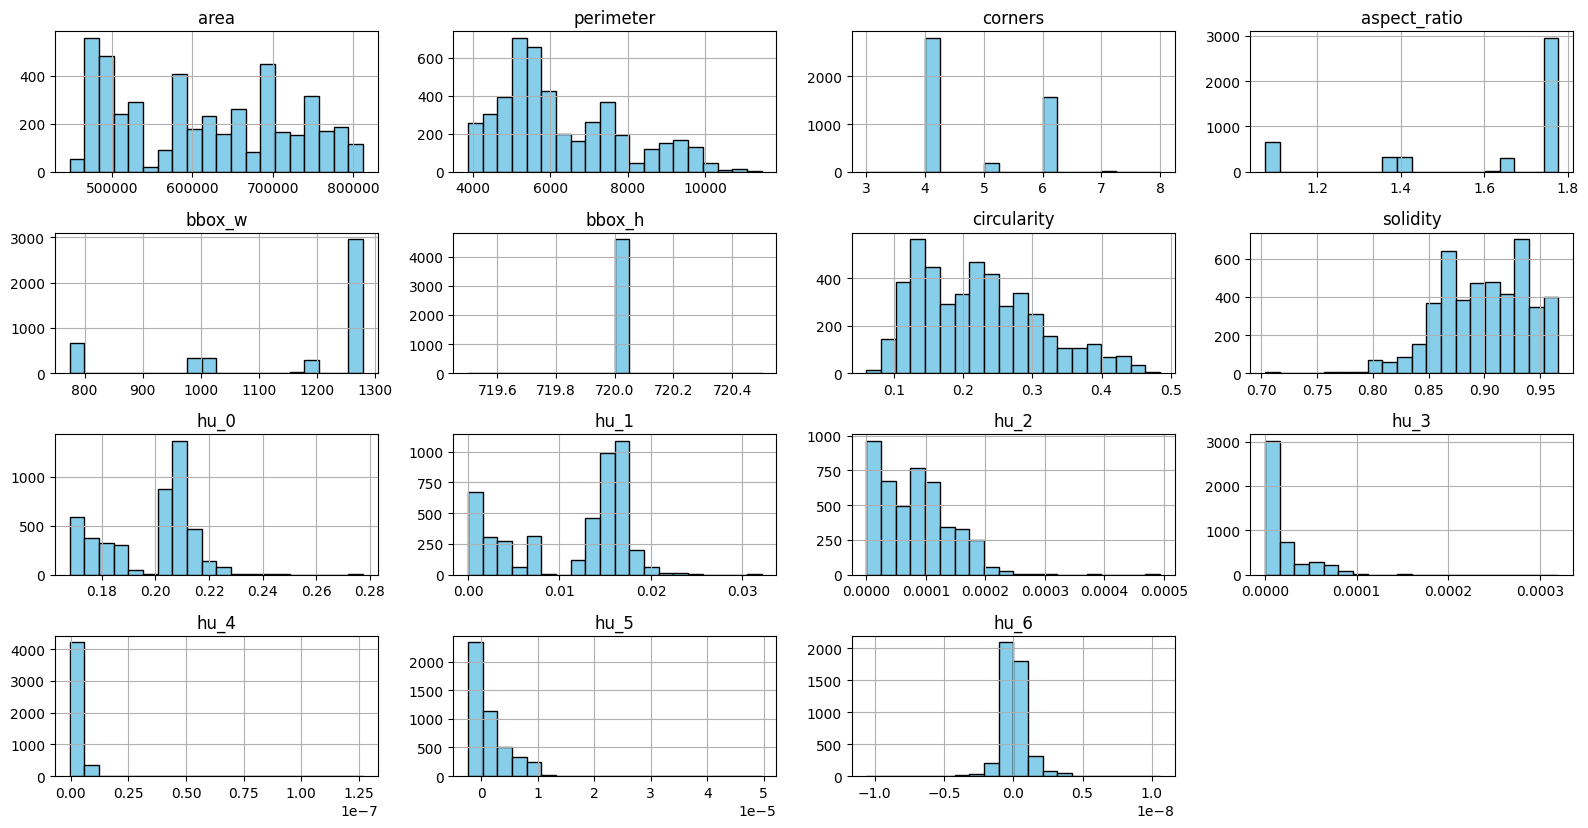

Mean feature values per label:


,area,perimeter,corners,aspect_ratio,bbox_w,bbox_h,circularity,solidity,hu_0,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6
label,,,,,,,,,,,,,,,
cat,614328.370335,6180.710526,4.727799,1.614927,1162.747104,720.0,0.232791,0.900787,0.197224,0.010854,0.000088,0.000017,1.496118e-09,0.000002,7.074133e-11
rejected,610044.088942,6428.942087,4.739698,1.614432,1162.390797,720.0,0.204777,0.893774,0.199719,0.011628,0.000076,0.000019,1.363817e-09,0.000002,1.133184e-10
unicorn,619939.840392,6229.296542,4.759166,1.614940,1162.756637,720.0,0.226984,0.904655,0.198029,0.011220,0.000080,0.000016,1.012057e-09,0.000002,6.104785e-11


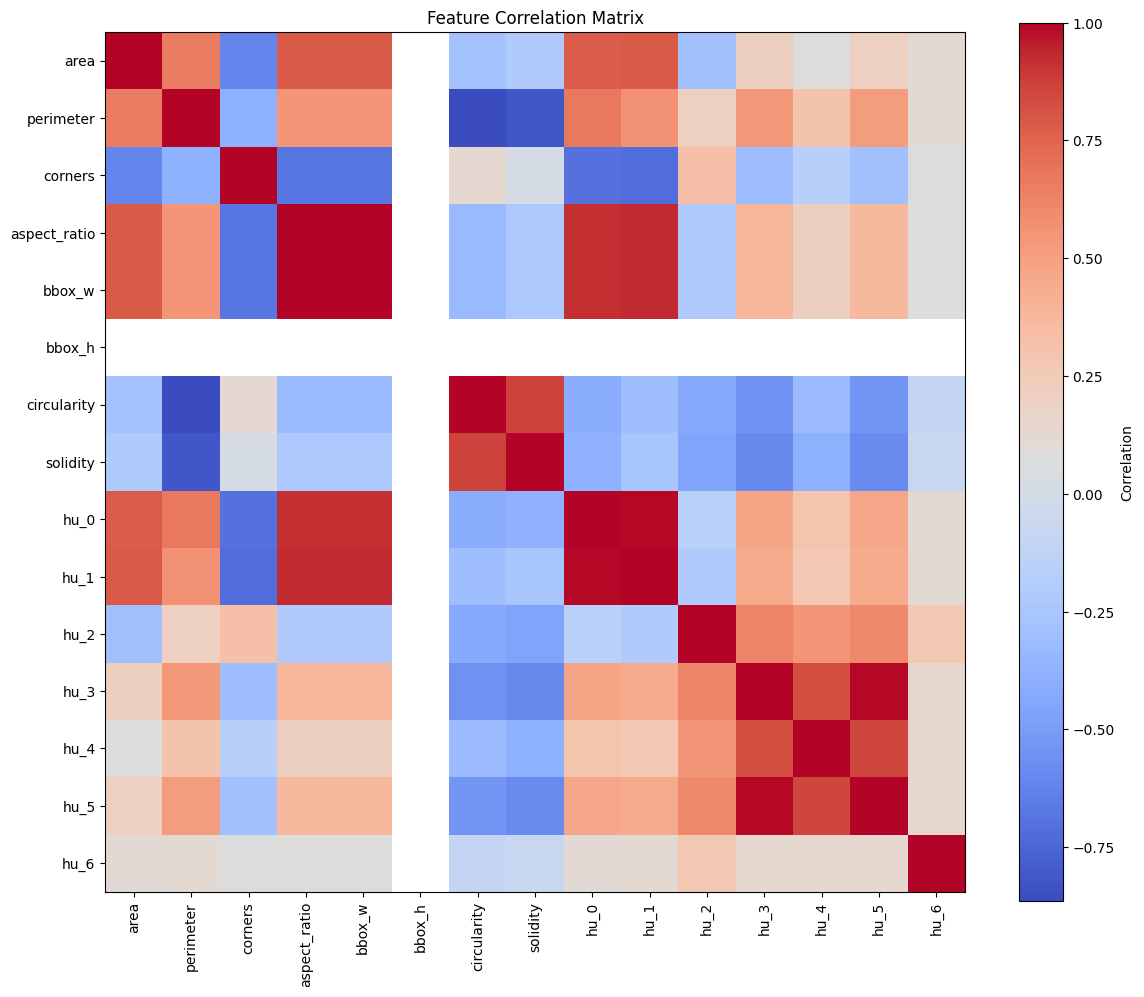

In [99]:
import matplotlib.pyplot as plt

print("Feature dataframe shape:", df.shape)
print("Label distribution:")
print(df["label"].value_counts())

print("Summary statistics:")
display(df.describe())

# Histogramme für numerische Merkmale
numeric_cols = df.select_dtypes(include=["number"]).columns
plt.figure(figsize=(16, 12))
df[numeric_cols].hist(bins=20, figsize=(16, 12), layout=(6, 4), color="skyblue", edgecolor="black")
plt.tight_layout()
plt.show()

# Mittelwerte der Merkmale pro Klasse
print("Mean feature values per label:")
display(df.groupby("label").mean())

# Korrelationsmatrix
corr_matrix = df.drop(columns=["label"]).corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="equal")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [100]:
X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [101]:
model = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [102]:
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         cat       0.68      0.75      0.71       311
    rejected       0.84      0.76      0.80       291
     unicorn       0.64      0.63      0.64       317

    accuracy                           0.71       919
   macro avg       0.72      0.72      0.72       919
weighted avg       0.72      0.71      0.71       919



In [103]:
joblib.dump(model, "decision_tree_model.pkl")
print("Model saved.")

Model saved.


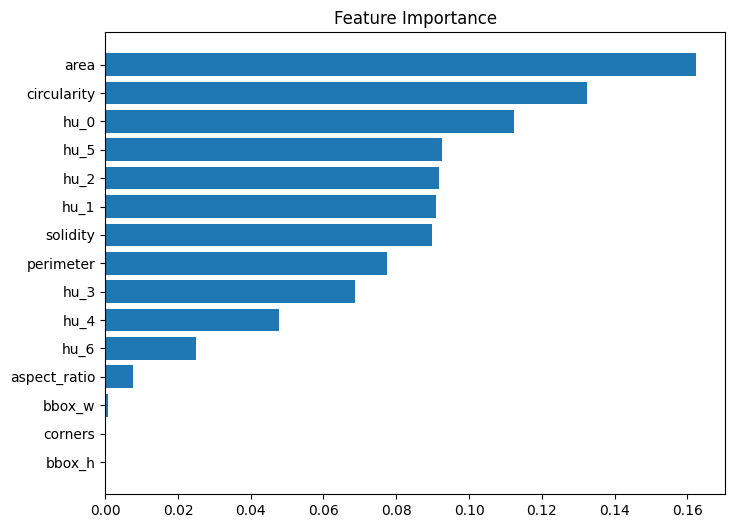

In [104]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
names = X.columns

idx = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh(names[idx], importances[idx])
plt.title("Feature Importance")
plt.show()